In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import re
import string
import emoji
import unicodedata
import nltk
import spacy
from spacy import displacy
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Emoji handling
import emoji

# Spell correction and contractions
from textblob import TextBlob
import contractions

# Multiprocessing and progress bars
from multiprocessing import Pool, cpu_count
from functools import lru_cache, partial
from tqdm import tqdm

# ML and encoding
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Deep learning tools
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Word embeddings
from gensim.models import Word2Vec

In [2]:
# Setup NLP resources
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
spacy_nlp = spacy.load("en_core_web_sm")
lemmatizer = WordNetLemmatizer()

In [3]:
# Load spaCy model for NER
import en_core_web_sm
nlp_spacy = en_core_web_sm.load()

# Disable unnecessary components for faster NER
nlp_spacy.disable_pipes("tagger", "parser", "lemmatizer")

['tagger', 'parser', 'lemmatizer']

In [4]:
# Load Data
corpus_df = pd.read_csv("./Sentiment_Data.csv", encoding="ISO-8859-1")

In [5]:
# Check the head of the dataframe
corpus_df.head()

,Tweet,Sentiment
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos


In [6]:
# Show data overview
print("Dataset Overview:")
print(f"Dataset shape: {corpus_df.shape}")
print(f"Columns: {corpus_df.columns.tolist()}")
print("\nSentiment Distribution:")
print(corpus_df['Sentiment'].value_counts())

Dataset Overview:
Dataset shape: (451332, 2)
Columns: ['Tweet', 'Sentiment']

Sentiment Distribution:
Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


In [7]:
# Create abbreviation dictionary
slang_dict = {
    "u": "you",
    "ur": "your",
    "n": "and",
    "2": "to",
    "4": "for",
    "w/": "with",
    "w/o": "without",
    "thru": "through",
    "tho": "though",
    "gonna": "going to",
    "wanna": "want to",
    "gotta": "got to",
    "kinda": "kind of",
    "sorta": "sort of",
    "outta": "out of",
    "dunno": "don't know",
    "gimme": "give me",
    "lemme": "let me",
    "btw": "by the way",
    "omg": "oh my god",
    "lol": "laugh out loud",
    "rofl": "rolling on floor laughing",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "aka": "also known as",
    "asap": "as soon as possible",
    "fyi": "for your information",
    "diy": "do it yourself",
    "faq": "frequently asked questions",
    "irl": "in real life",
    "ppl": "people",
    "msg": "message",
    "txt": "text",
    "pic": "picture",
    "vid": "video",
    "app": "application",
    "tech": "technology",
    "biz": "business",
    "edu": "education",
    "gov": "government",
    "org": "organization",
    "info": "information",
    "omg": "oh my god",
    "lol": "laugh out loud",
    "btw": "by the way",
    "idk": "i do not know",
    "smh": "shaking my head",
    "afaik": "as far as i know",
    "tbh": "to be honest",
    "imo": "in my opinion",
    "icymi": "in case you missed it",
    "fwiw": "for what it is worth",
    "ftw": "for the win",
    "lmk": "let me know",
    "rn": "right now",
    "thx": "thanks",
    "til": "today i learned",
    "brb": "be right back",
    "gg": "good game",
    "noob": "newbie",
    "ootd": "outfit of the day",
    "fyp": "for you page",
    "hmu": "hit me up",
    "iiuc": "if i understand correctly",
    "ikr": "i know, right",
    "irl": "in real life",
    "iss": "i am so sorry",
    "jsyk": "just so you know",
    "lowkey": "quietly",
    "highkey": "obviously",
    "ngl": "not gonna lie",
    "oot": "out of the",
    "pls": "please",
    "rizz": "charisma",
    "ship": "support a romantic relationship",
    "slay": "do something well",
    "s/o": "shoutout",
    "stan": "support",
    "tbf": "to be fair",
    "tea": "gossip",
    "vibe check": "evaluation of mood",
    "wtf": "what the freak",
    "wym": "what you mean",
    "yaaas": "strong agreement",
    "cc": "carbon-copy",
    "cx": "correction",
    "ct": "cut tweet",
    "dm": "direct message",
    "ht": "hat tip",
    "mt": "modified tweet",
    "prt": "please retweet",
    "rt": "retweet",
    "em": "email marketing",
    "ezine": "electronic magazine",
    "fb": "facebook",
    "li": "linkedin",
    "seo": "search engine optimization",
    "sm": "social media",
    "smm": "social media marketing",
    "smo": "social media optimization",
    "sn": "social network",
    "sroi": "social return on investment",
    "ugc": "user generated content",
    "yt": "youtube",
    "ab/abt": "about",
    "b4": "before",
    "bfn": "bye for now",
    "bgd": "background",
    "bh": "blockhead",
    "br": "best regards",
    "cd9": "code 9",
    "chk": "check",
    "cul8r": "see you later",
    "dam": "don not annoy me",
    "dd": "dear daughter",
    "df": "dear fiancé",
    "dp": "profile pic",
    "ds": "dear son",
    "dyk": "did you know, do you know",
    "ema": "email address",
    "ftf": "face to face",
    "f2f": "face to face",
    "ff": "follow friday",
    "fotd": "find of the day",
    "gts": "guess the song",
    "hagn": "have a good night",
    "hand": "have a nice day",
    "hotd": "headline of the day",
    "hth": "hope that helps",
    "ic": "i see",
    "iirc": "if i remember correctly",
    "jk": "just kidding, joke",
    "jv": "joint venture",
    "kk": "ok got it",
    "kyso": "knock your socks off",
    "lhh": "laugh hella hard",
    "lmao": "laughing my ass off",
    "lo": "little one",
    "mm": "music monday",
    "mirl": "meet in real life",
    "nbd": "no big deal",
    "nct": "nobody cares, though",
    "nfw": "no freaking way",
    "njoy": "enjoy",
    "nsfw": "not safe for work",
    "nts": "note to self",
    "oh": "overheard",
    "omfg": "oh my freaking god",
    "oomf": "one of my followers",
    "orly": "oh really",
    "plmk": "please let me know",
    "pnp": "party and play",
    "qotd": "quote of the day",
    "re": "in reply to, in regards to",
    "rlrt": "real-life re-tweet",
    "rtq": "read the question",
    "sfw": "safe for work",
    "smdh": "shaking my damn head",
    "so": "significant other",
    "srs": "serious",
    "tftf": "thanks for the follow",
    "tf": "thanks for this tweet",
    "tj": "tweetjack",
    "tl": "timeline",
    "tldr": "too long, did not read",
    "tmb": "tweet me back",
    "tt": "trending topic",
    "tyia": "thank you in advance",
    "tyt": "take your time",
    "tyvw": "thank you very much",
    "w/": "with",
    "w/e": "weekend",
    "wtv": "whatever",
    "ygtr": "you got that right",
    "ykwim": "you know what i mean",
    "ykyat": "you know you are addicted to",
    "ymmv": "your mileage may vary",
    "yolo": "you only live once",
    "yoyo": "you are on your own",
    "yw": "you are welcome",
    "zomg": "omg to the max"
}
lemmatizer = WordNetLemmatizer()

### Text Cleaning Functions

In [8]:
# Function to clean dataset
def process_emojis_symbols(text):
    if not isinstance(text, str):
        return ""
    # Process emojis
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Remove non-grammatical symbols
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)  # URLs
    text = re.sub(r'@\w+', ' ', text)                   # Mentions
    text = re.sub(r'#(\w+)', r'\1', text)               # hashtags keep text
    text = re.sub(r'[^a-zA-Z0-9\s\-]', ' ', text)       # non-alphanum except hyphens    

    # Expand contractions
    text = contractions.fix(text)

    return text

# Named Entity Recognition Processing
def extract_entities(text):
    return " ".join([ent.text for ent in nlp_spacy(text).ents]) or text

# Parallel processing helper
def batch_process(texts, func):
    with Pool() as pool:
        return list(tqdm(pool.imap(func, texts, chunksize=1000), total=len(texts)))

# Spelling corrections
def correct_spelling(text):
    return str(TextBlob(text).correct()) if isinstance(text, str) else ""

# Slang and Abbreviation handler
def expand_slangs(text):
    return ' '.join([slang_dict.get(word, word) for word in text.split()])

# Non-grammatical punctuation removal
def remove_punctuations(text):
    text = re.sub(r'[^\w\s-]', ' ', text)  # Keep hyphens
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Lemmatize the text
def lemmatize_text(text):
    doc = nlp_spacy(text)
    return " ".join(token.lemma_ for token in doc)

### Complete Pipeline

In [9]:
def clean_pipeline(text):
    text = process_emojis_symbols(text)
    # text = extract_entities(text) Skipped due to excessive computational requirements
    text = text.lower()
    # text = correct_spelling(text) Skipped due to excessive computational requirements
    text = expand_slangs(text)
    text = remove_punctuations(text)
    text = lemmatize_text(text)
    return text

In [10]:
corpus_df['Tweet'] = corpus_df['Tweet'].fillna("")

In [11]:
# Processing the pipeline
tqdm.pandas()
corpus_df['Cleaned_Text'] = corpus_df['Tweet'].progress_apply(clean_pipeline)

100%|██████████| 451332/451332 [29:10<00:00, 257.89it/s] 


In [12]:
# Check the new dataframe
corpus_df.head()

,Tweet,Sentiment,Cleaned_Text
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos,
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos,
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos,
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos,
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos,


### Check the Data Quality

In [13]:
# Data Quality Report
print("\n=== Data Quality Report ===")
print(f"Total samples: {len(corpus_df):,}")
print(f"Missing values: {corpus_df['Cleaned_Text'].isnull().sum():,}")
print(f"Empty strings after cleaning: {corpus_df['Cleaned_Text'].eq('').sum():,}")


=== Data Quality Report ===
Total samples: 451,332
Missing values: 0
Empty strings after cleaning: 1,750


In [14]:
# Remove empty texts
corpus_df = corpus_df[corpus_df['Cleaned_Text'].str.strip().astype(bool)]

### Consolidate Sentiments

In [15]:
# Merge sentiment categories
def merge_sentiments(sentiment):
    if sentiment in ['Mild_Pos', 'Strong_Pos']:
        return 'Positive'
    elif sentiment in ['Mild_Neg', 'Strong_Neg']:
        return 'Negative'
    else:
        return 'Neutral'

corpus_df['Sentiment_Merged'] = corpus_df['Sentiment'].apply(merge_sentiments)
print("\nMerged Sentiment Distribution:")
print(corpus_df['Sentiment_Merged'].value_counts())


Merged Sentiment Distribution:
Sentiment_Merged
Positive    165
Negative     57
Neutral      32
Name: count, dtype: int64


In [16]:
# Balance dataset
sample_size = 30000
print(f"Balancing dataset with {sample_size} samples per class.")

def balance_dataset(df, target_col='Sentiment_Merged', min_count=None):
    if min_count is None:
        min_count = df[target_col].value_counts().min()

    balanced_dfs = []
    for sentiment in df[target_col].unique():
        sentiment_df = df[df[target_col] == sentiment]
        if len(sentiment_df) > min_count:
            balanced_df = sentiment_df.sample(n=min_count, random_state=42)
        else:
            balanced_df = sentiment_df
        balanced_dfs.append(balanced_df)

    return pd.concat(balanced_dfs, ignore_index=True)

balanced_corpus = balance_dataset(corpus_df, min_count=sample_size)
print(f"Balanced dataset shape: {balanced_corpus.shape}")

Balancing dataset with 30000 samples per class.
Balanced dataset shape: (254, 4)


In [17]:
corpus_df = balance_dataset(corpus_df, min_count=sample_size)
print(f"Balanced dataset shape: {balanced_corpus.shape}")
print("Balanced sentiment distribution:")
print(corpus_df['Sentiment_Merged'].value_counts())

Balanced dataset shape: (254, 4)
Balanced sentiment distribution:
Sentiment_Merged
Positive    165
Negative     57
Neutral      32
Name: count, dtype: int64


### Prepare encodings and Train-Test Splits for Models

In [18]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(corpus_df['Sentiment_Merged'])

vocab_size = 10000
max_len = 250

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(corpus_df['Cleaned_Text'])
sequences = tokenizer.texts_to_sequences(corpus_df['Cleaned_Text'])
pad_sequences_data = pad_sequences(sequences, maxlen=max_len, truncating='post')

X_train, X_test, y_train, y_test = train_test_split(
    pad_sequences_data, y, test_size=0.2, random_state=42, stratify=y)

### Compute Class Weights

In [19]:
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

### Save Processed Datasets & Processing Tools

In [20]:
import pickle
import os
save_dir = "./processed_data/"
os.makedirs(save_dir, exist_ok=True)

np.save(f"{save_dir}X_train.npy", X_train)
np.save(f"{save_dir}X_test.npy", X_test)
np.save(f"{save_dir}y_train.npy", y_train)
np.save(f"{save_dir}y_test.npy", y_test)

with open(f"{save_dir}tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
with open(f"{save_dir}label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
with open(f"{save_dir}class_weights.pkl", "wb") as f:
    pickle.dump(class_weight_dict, f)

corpus_df.to_csv(f"{save_dir}Cleaned_Dataset.csv", index=False)

### Summary Report

In [21]:
import time
start_time = time.time()
# Run the preprocessing pipeline here
processing_time = time.time() - start_time

summary = f"""
PREPROCESSING SUMMARY
================================

Dataset Information:
- Total tweets: {len(corpus_df):,}
- Train set: {len(X_train):,}
- Test set: {len(X_test):,}
- Vocabulary size: {vocab_size:,}
- Processing time: {processing_time:.2f} seconds
- Processing speed: {len(corpus_df)/processing_time:.0f} tweets/second

Preprocessing Steps Completed:
✓ Emoji processing (converted to text)
✓ Non-grammatical symbol removal
✓ Named Entity Recognition # Skipped
✓ Spell correction # Skipped
✓ Abbreviation expansion
✓ Contraction expansion
✓ Punctuation cleaning
✓ Tokenization
✓ Lemmatization

Model-Ready Data Created:
✓ LSTM data: X_train_lstm.npy, X_test_lstm.npy
✓ Transformer data: X_train_transformer.npy, X_test_transformer.npy
✓ Word2Vec embeddings: w2v_embedding_matrix.npy
✓ Categorical labels: y_train.npy, y_test.npy

Ready for Models:
1. ✓ Bidirectional LSTM with learnable embeddings
2. ✓ Causal transformer with learnable embeddings
3. ✓ Causal transformer with FastText/ELMo embeddings
4. ✓ Non-causal transformer with Word2Vec embeddings
5. ✓ Non-causal transformer with learnable embeddings

Configuration saved in: tokenizer.pkl, label_encoder.pkl, class_weights.pkl
Class weights: {class_weight_dict}
"""

with open(f"{save_dir}SUMMARY.txt", "w") as f:
    f.write(summary)
print(summary)
print("PREPROCESSING COMPLETE")
print(f"All data saved to: {save_dir}")


PREPROCESSING SUMMARY

Dataset Information:
- Total tweets: 254
- Train set: 203
- Test set: 51
- Vocabulary size: 10,000
- Processing time: 0.00 seconds
- Processing speed: 21307064 tweets/second

Preprocessing Steps Completed:
✓ Emoji processing (converted to text)
✓ Non-grammatical symbol removal
✓ Named Entity Recognition # Skipped
✓ Spell correction # Skipped
✓ Abbreviation expansion
✓ Contraction expansion
✓ Punctuation cleaning
✓ Tokenization
✓ Lemmatization

Model-Ready Data Created:
✓ LSTM data: X_train_lstm.npy, X_test_lstm.npy
✓ Transformer data: X_train_transformer.npy, X_test_transformer.npy
✓ Word2Vec embeddings: w2v_embedding_matrix.npy
✓ Categorical labels: y_train.npy, y_test.npy

Ready for Models:
1. ✓ Bidirectional LSTM with learnable embeddings
2. ✓ Causal transformer with learnable embeddings
3. ✓ Causal transformer with FastText/ELMo embeddings
4. ✓ Non-causal transformer with Word2Vec embeddings
5. ✓ Non-causal transformer with learnable embeddings

Configuratio

## 5. Non-causal Transformer model using embedding layer with position embeddings

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score
import numpy as np
import pickle
import os

# Load preprocessed data
# data_dir = "C://PG AI and DS//Semester 3//processed_data/"
data_dir = "./processed_data1"

X_train = np.load(os.path.join(data_dir, "X_train.npy"))
X_test = np.load(os.path.join(data_dir, "X_test.npy"))
y_train = np.load(os.path.join(data_dir, "y_train.npy"))
y_test = np.load(os.path.join(data_dir, "y_test.npy"))

with open(os.path.join(data_dir, "tokenizer.pkl"), "rb") as f:
    tokenizer = pickle.load(f)
with open(os.path.join(data_dir, "class_weights.pkl"), "rb") as f:
    class_weights = pickle.load(f)
with open(os.path.join(data_dir, "label_encoder.pkl"), "rb") as f:
    label_encoder = pickle.load(f)

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vocab_size = 10000
max_len = 250
embed_dim = 128
num_heads = 4
hidden_dim = 256
num_layers = 2
num_classes = len(np.unique(y_train))
batch_size = 16

# Class weight tensor
class_weights_tensor = torch.tensor(
    [class_weights[i] for i in range(num_classes)],
    dtype=torch.float32
).to(device)

# Dataset and DataLoader
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.long),
    torch.tensor(y_train, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.long),
    torch.tensor(y_test, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


In [53]:
class PositionalEmbedding(nn.Module):
    def __init__(self, max_len, embed_dim):
        super().__init__()
        self.position_embedding = nn.Embedding(max_len, embed_dim)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        positions = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)
        return self.position_embedding(positions)

class NonCausalTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, max_len, num_heads, hidden_dim, num_layers, num_classes):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.positional_embedding = PositionalEmbedding(max_len, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=hidden_dim)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)

        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        token_emb = self.token_embedding(x)
        pos_emb = self.positional_embedding(x)
        x = token_emb + pos_emb  # Combine embeddings
        x = x.permute(1, 0, 2)   # (seq_len, batch, embed)
        x = self.transformer(x)
        x = x.permute(1, 0, 2)   # (batch, seq_len, embed)
        x = x.mean(dim=1)        # Mean pooling
        return self.classifier(x)


In [54]:
model = NonCausalTransformer(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    max_len=max_len,
    num_heads=num_heads,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
import time
from sklearn.metrics import accuracy_score

EPOCHS = 5
model.train()

total_start_time = time.time()  # Start total training timer

for epoch in range(EPOCHS):
    epoch_start_time = time.time()
    total_loss = 0
    all_preds = []
    all_labels = []

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(targets.cpu().numpy())

    avg_loss = total_loss / len(train_loader)
    epoch_accuracy = accuracy_score(all_labels, all_preds)
    epoch_time = time.time() - epoch_start_time

    print(f"✅ Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f} - Accuracy: {epoch_accuracy:.4f} - Time: {epoch_time:.2f} sec")

total_training_time = time.time() - total_start_time
print(f"\n⏱️ Total Training Time for {EPOCHS} Epochs: {total_training_time:.2f} sec")


✅ Epoch 1/5 - Loss: 0.8777 - Accuracy: 0.5892 - Time: 504.77 sec
✅ Epoch 2/5 - Loss: 0.7543 - Accuracy: 0.6684 - Time: 507.82 sec
✅ Epoch 3/5 - Loss: 0.6967 - Accuracy: 0.6994 - Time: 504.38 sec
✅ Epoch 4/5 - Loss: 0.6527 - Accuracy: 0.7221 - Time: 508.78 sec
✅ Epoch 5/5 - Loss: 0.6142 - Accuracy: 0.7399 - Time: 508.53 sec

⏱️ Total Training Time for 5 Epochs: 2534.33 sec


In [55]:
import time
from sklearn.metrics import accuracy_score

EPOCHS = 10
model.train()

total_start_time = time.time()  # Start total training timer

for epoch in range(EPOCHS):
    epoch_start_time = time.time()
    total_loss = 0
    all_preds = []
    all_labels = []

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(targets.cpu().numpy())

    avg_loss = total_loss / len(train_loader)
    epoch_accuracy = accuracy_score(all_labels, all_preds)
    epoch_time = time.time() - epoch_start_time

    print(f"✅ Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f} - Accuracy: {epoch_accuracy:.4f} - Time: {epoch_time:.2f} sec")

total_training_time = time.time() - total_start_time
print(f"\n⏱️ Total Training Time for {EPOCHS} Epochs: {total_training_time:.2f} sec")


✅ Epoch 1/10 - Loss: 0.8763 - Accuracy: 0.5895 - Time: 510.13 sec
✅ Epoch 2/10 - Loss: 0.7520 - Accuracy: 0.6684 - Time: 537.25 sec
✅ Epoch 3/10 - Loss: 0.6937 - Accuracy: 0.7001 - Time: 647.06 sec
✅ Epoch 4/10 - Loss: 0.6502 - Accuracy: 0.7221 - Time: 804.52 sec
✅ Epoch 5/10 - Loss: 0.6141 - Accuracy: 0.7391 - Time: 3716.44 sec
✅ Epoch 6/10 - Loss: 0.5845 - Accuracy: 0.7532 - Time: 3441.07 sec
✅ Epoch 7/10 - Loss: 0.5561 - Accuracy: 0.7674 - Time: 2295.26 sec
✅ Epoch 8/10 - Loss: 0.5311 - Accuracy: 0.7778 - Time: 1058.46 sec
✅ Epoch 9/10 - Loss: 0.5088 - Accuracy: 0.7882 - Time: 2448.51 sec
✅ Epoch 10/10 - Loss: 0.4852 - Accuracy: 0.8010 - Time: 586.64 sec

⏱️ Total Training Time for 10 Epochs: 16045.41 sec


In [56]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

model.eval()
all_preds, all_targets, all_probs = [], [], []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())  # Save full probability vector

# Convert to numpy
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs = np.array(all_probs)

# Evaluation metrics
cm = confusion_matrix(all_targets, all_preds)
f1_macro = f1_score(all_targets, all_preds, average='macro')
f1_weighted = f1_score(all_targets, all_preds, average='weighted')
acc = accuracy_score(all_targets, all_preds)

# ROC AUC (for multiclass)
try:
    y_true_bin = label_binarize(all_targets, classes=list(range(num_classes)))
    auc = roc_auc_score(y_true_bin, all_probs, average='macro', multi_class='ovo')
except ValueError:
    auc = None  # AUC may fail if only one class present

# Print metrics
print("\n📊 First-Level Evaluation Metrics:")
print("Confusion Matrix:\n", cm)
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")
if auc is not None:
    print(f"AUC Score (Multiclass): {auc:.4f}")
else:
    print("AUC Score: Not available (only one class in test data)")
print(f"Accuracy: {acc:.4f}")



📊 First-Level Evaluation Metrics:
Confusion Matrix:
 [[4769  757  474]
 [1375 3775  850]
 [ 744  520 4736]]
F1 Score (Macro): 0.7362
F1 Score (Weighted): 0.7362
AUC Score (Multiclass): 0.8958
Accuracy: 0.7378


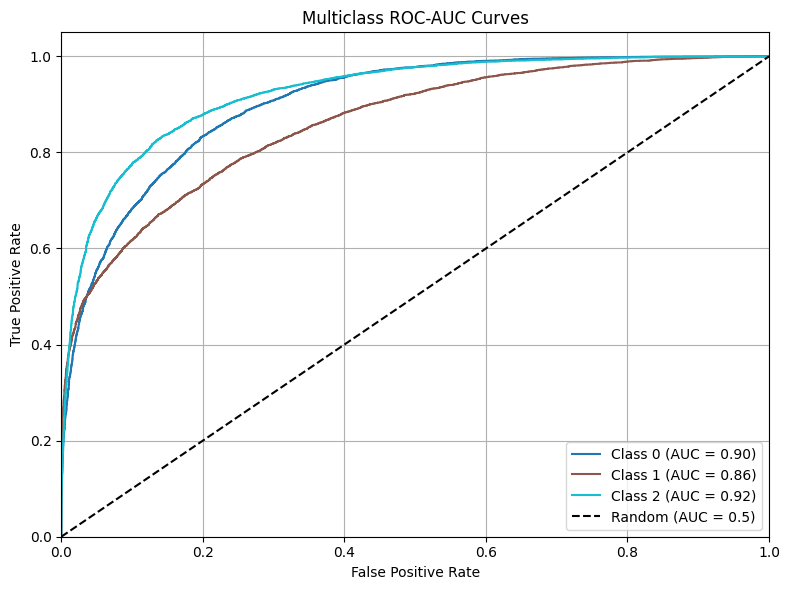

In [57]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# One-hot encode true labels
y_true_bin = label_binarize(all_targets, classes=list(range(num_classes)))
fpr = dict()
tpr = dict()
roc_auc = dict()

# Compute ROC curve and ROC area for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = plt.cm.get_cmap('tab10', num_classes)

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i],
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})',
             color=colors(i))

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC-AUC Curves')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


### First Empirical Tuning

In [58]:
# First checking for train evaluation
# ---- TRAINING SET EVALUATION ----
model.eval()
train_preds, train_targets, train_probs = [], [], []

with torch.no_grad():
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(targets.cpu().numpy())
        train_probs.extend(probs.cpu().numpy())

# Convert to numpy
train_preds = np.array(train_preds)
train_targets = np.array(train_targets)
train_probs = np.array(train_probs)

# Evaluation metrics
train_acc = accuracy_score(train_targets, train_preds)
train_f1_macro = f1_score(train_targets, train_preds, average='macro')
train_f1_weighted = f1_score(train_targets, train_preds, average='weighted')
try:
    y_train_bin = label_binarize(train_targets, classes=list(range(num_classes)))
    train_auc = roc_auc_score(y_train_bin, train_probs, average='macro', multi_class='ovo')
except ValueError:
    train_auc = None

In [46]:
# Print metrics for train vs test

print("\n📊 Evaluation Metrics:")

print("\n🔹 Train Metrics:")
print(f"Accuracy: {train_acc:.4f}")
print(f"F1 Score (Macro): {train_f1_macro:.4f}")
print(f"F1 Score (Weighted): {train_f1_weighted:.4f}")
print(f"AUC Score (Multiclass): {train_auc:.4f}" if train_auc else "AUC Score: Not available")

print("\n🔹 Test Metrics:")
print("Confusion Matrix:\n", cm)
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")
print(f"AUC Score (Multiclass): {auc:.4f}" if isinstance(auc, float) else "AUC Score: Not available")


📊 Evaluation Metrics:

🔹 Train Metrics:
Accuracy: 0.7601
F1 Score (Macro): 0.7588
F1 Score (Weighted): 0.7588
AUC Score (Multiclass): 0.9095

🔹 Test Metrics:
Confusion Matrix:
 [[4276 1001  723]
 [1107 3905  988]
 [ 444  754 4802]]
Accuracy: 0.7213
F1 Score (Macro): 0.7201
F1 Score (Weighted): 0.7201
AUC Score: Not available


In [59]:
# Create a table with the metrics
metrics = {
    "Set": ["Train", "Test"],
    "Accuracy": [train_acc, acc],
    "F1 Macro": [train_f1_macro, f1_macro],
    "F1 Weighted": [train_f1_weighted, f1_weighted],
    "AUC": [
        train_auc if train_auc is not None else "N/A",
        auc if auc is not None else "N/A"
    ]
}

# Dataframe with metrics
eval_metrics = pd.DataFrame(metrics)

print(eval_metrics)

     Set  Accuracy  F1 Macro  F1 Weighted                            AUC
0  Train  0.825139  0.823651     0.823651                       0.948762
1   Test  0.737778  0.736203     0.736203  <function auc at 0x16a8ca660>


##### Problem 1: Overfitting

In [60]:
# Updating the optimizer with weight decay
model = NonCausalTransformer(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    max_len=max_len,
    num_heads=num_heads,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5) #added L2 regularizer(weight decay)


In [61]:
import time
from sklearn.metrics import accuracy_score

EPOCHS = 10
model.train()

total_start_time = time.time()  # Start total training timer

for epoch in range(EPOCHS):
    epoch_start_time = time.time()
    total_loss = 0
    all_preds = []
    all_labels = []

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(targets.cpu().numpy())

    avg_loss = total_loss / len(train_loader)
    epoch_accuracy = accuracy_score(all_labels, all_preds)
    epoch_time = time.time() - epoch_start_time

    print(f"✅ Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f} - Accuracy: {epoch_accuracy:.4f} - Time: {epoch_time:.2f} sec")

total_training_time = time.time() - total_start_time
print(f"\n⏱️ Total Training Time for {EPOCHS} Epochs: {total_training_time:.2f} sec")


✅ Epoch 1/10 - Loss: 0.8694 - Accuracy: 0.5943 - Time: 579.41 sec
✅ Epoch 2/10 - Loss: 0.7642 - Accuracy: 0.6611 - Time: 3770.31 sec
✅ Epoch 3/10 - Loss: 0.7095 - Accuracy: 0.6903 - Time: 588.19 sec
✅ Epoch 4/10 - Loss: 0.6668 - Accuracy: 0.7134 - Time: 577.44 sec
✅ Epoch 5/10 - Loss: 0.6331 - Accuracy: 0.7314 - Time: 508.37 sec
✅ Epoch 6/10 - Loss: 0.6038 - Accuracy: 0.7473 - Time: 506.80 sec
✅ Epoch 7/10 - Loss: 0.5742 - Accuracy: 0.7598 - Time: 556.14 sec
✅ Epoch 8/10 - Loss: 0.5473 - Accuracy: 0.7728 - Time: 619.19 sec
✅ Epoch 9/10 - Loss: 0.5225 - Accuracy: 0.7846 - Time: 774.13 sec
✅ Epoch 10/10 - Loss: 0.4979 - Accuracy: 0.7957 - Time: 570.15 sec

⏱️ Total Training Time for 10 Epochs: 9050.20 sec


In [63]:

# ---- TRAINING SET EVALUATION AFTER REGULARIZATION ----
model.eval()
train_preds, train_targets, train_probs = [], [], []

with torch.no_grad():
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1,)

        preds = torch.argmax(probs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(targets.cpu().numpy())
        train_probs.extend(probs.cpu().numpy())

# Convert to numpy
train_preds = np.array(train_preds)
train_targets = np.array(train_targets)
train_probs = np.array(train_probs)

# Evaluation metrics
train_acc = accuracy_score(train_targets, train_preds)
train_f1_macro = f1_score(train_targets, train_preds, average='macro')
train_f1_weighted = f1_score(train_targets, train_preds, average='weighted')
try:
    y_train_bin = label_binarize(train_targets, classes=list(range(num_classes)))
    train_auc = roc_auc_score(y_train_bin, train_probs, average='macro', multi_class='ovo')
except ValueError:
    train_auc = None

In [ ]:
# Add metrics to eval_metrics table
metrics_row_addition = {
    "Set": "Train-reg",
    "Accuracy": train_acc,
    "F1 Macro": train_f1_macro,
    "F1 Weighted": train_f1_weighted,
    "AUC": train_auc
}

eval_metrics = pd.concat([eval_metrics, pd.DataFrame([metrics_row_addition])])
print(eval_metrics)

         Set  Accuracy  F1 Macro  F1 Weighted                            AUC
0      Train  0.825139  0.823651     0.823651                       0.948762
1       Test  0.737778  0.736203     0.736203  <function auc at 0x16a8ca660>
0  Train-reg  0.816431  0.814244     0.814244                       0.946015


In [75]:
eval_metrics = eval_metrics.reset_index(drop=True)
print(eval_metrics)

         Set  Accuracy  F1 Macro  F1 Weighted                            AUC
0      Train  0.825139  0.823651     0.823651                       0.948762
1       Test  0.737778  0.736203     0.736203  <function auc at 0x16a8ca660>
2  Train-reg  0.816431  0.814244     0.814244                       0.946015


In [76]:
# ---- TEST SET EVALUATION AFTER REGULARIZATION ----

model.eval()
all_preds, all_targets, all_probs = [], [], []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())  # Save full probability vector

# Convert to numpy
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs = np.array(all_probs)

# Evaluation metrics
cm = confusion_matrix(all_targets, all_preds)
f1_macro = f1_score(all_targets, all_preds, average='macro')
f1_weighted = f1_score(all_targets, all_preds, average='weighted')
acc = accuracy_score(all_targets, all_preds)

# ROC AUC (for multiclass)
try:
    y_true_bin = label_binarize(all_targets, classes=list(range(num_classes)))
    auc = roc_auc_score(y_true_bin, all_probs, average='macro', multi_class='ovo')
except ValueError:
    auc = None  # AUC may fail if only one class present


In [ ]:
# Add test metrics to eval_metrics table
metrics_row_addition = {
    "Set": "Test-reg",
    "Accuracy": acc,
    "F1 Macro": f1_macro,
    "F1 Weighted": f1_weighted,
    "AUC": auc
}

eval_metrics = pd.concat([eval_metrics, pd.DataFrame([metrics_row_addition])])

print(eval_metrics)

         Set  Accuracy  F1 Macro  F1 Weighted                            AUC
0      Train  0.825139  0.823651     0.823651                       0.948762
1       Test  0.737778  0.736203     0.736203  <function auc at 0x16a8ca660>
2  Train-reg  0.816431  0.814244     0.814244                       0.946015
0   Test-reg  0.742500  0.740206     0.740206                       0.895912


### Second Empirical Tuning

In [84]:
#  Model is still overfitting. Add dropout layers 

class PositionalEmbedding(nn.Module):
    def __init__(self, max_len, embed_dim):
        super().__init__()
        self.position_embedding = nn.Embedding(max_len, embed_dim)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        positions = torch.arange(0, x.size(1), device=x.device).unsqueeze(0)
        return self.position_embedding(positions)

class NonCausalTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, max_len, num_heads, hidden_dim, num_layers, num_classes,
                 dropout=0.1): #Added dropout
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.positional_embedding = PositionalEmbedding(max_len, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=hidden_dim,
                                                   dropout=dropout) #Internal dropout in transformer layer
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        self.dropout = nn.Dropout(dropout) # Added dropout layer

        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        token_emb = self.token_embedding(x)
        pos_emb = self.positional_embedding(x)
        x = token_emb + pos_emb  # Combine embeddings

        x = self.dropout(x) # Dropout after embedding

        x = x.permute(1, 0, 2)   # (seq_len, batch, embed)
        x = self.transformer(x)
        x = x.permute(1, 0, 2)   # (batch, seq_len, embed)
        x = x.mean(dim=1)        # Mean pooling
        x = self.dropout(x) # Dropout before final classifier
        return self.classifier(x)


In [85]:
# Increase regularization strength

model = NonCausalTransformer(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    max_len=max_len,
    num_heads=num_heads,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes,
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4) #increased L2 regularizer(weight decay)

In [86]:
import time
from sklearn.metrics import accuracy_score

EPOCHS = 10
model.train()

total_start_time = time.time()  # Start total training timer

for epoch in range(EPOCHS):
    epoch_start_time = time.time()
    total_loss = 0
    all_preds = []
    all_labels = []

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(targets.cpu().numpy())

    avg_loss = total_loss / len(train_loader)
    epoch_accuracy = accuracy_score(all_labels, all_preds)
    epoch_time = time.time() - epoch_start_time

    print(f"✅ Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f} - Accuracy: {epoch_accuracy:.4f} - Time: {epoch_time:.2f} sec")

total_training_time = time.time() - total_start_time
print(f"\n⏱️ Total Training Time for {EPOCHS} Epochs: {total_training_time:.2f} sec")


✅ Epoch 1/10 - Loss: 0.9018 - Accuracy: 0.5723 - Time: 883.80 sec
✅ Epoch 2/10 - Loss: 0.8222 - Accuracy: 0.6289 - Time: 545.19 sec
✅ Epoch 3/10 - Loss: 0.7875 - Accuracy: 0.6493 - Time: 540.36 sec
✅ Epoch 4/10 - Loss: 0.7542 - Accuracy: 0.6694 - Time: 513.11 sec
✅ Epoch 5/10 - Loss: 0.7212 - Accuracy: 0.6860 - Time: 510.18 sec
✅ Epoch 6/10 - Loss: 0.6910 - Accuracy: 0.7045 - Time: 520.44 sec
✅ Epoch 7/10 - Loss: 0.6663 - Accuracy: 0.7154 - Time: 515.98 sec
✅ Epoch 8/10 - Loss: 0.6403 - Accuracy: 0.7292 - Time: 511.46 sec
✅ Epoch 9/10 - Loss: 0.6218 - Accuracy: 0.7367 - Time: 516.16 sec
✅ Epoch 10/10 - Loss: 0.6038 - Accuracy: 0.7464 - Time: 585.27 sec

⏱️ Total Training Time for 10 Epochs: 5642.05 sec


In [87]:

# ---- TRAINING SET EVALUATION AFTER DROPOUT AND STRONGER REGULARIZATION ----
model.eval()
train_preds, train_targets, train_probs = [], [], []

with torch.no_grad():
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1,)

        preds = torch.argmax(probs, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(targets.cpu().numpy())
        train_probs.extend(probs.cpu().numpy())

# Convert to numpy
train_preds = np.array(train_preds)
train_targets = np.array(train_targets)
train_probs = np.array(train_probs)

# Evaluation metrics
train_acc = accuracy_score(train_targets, train_preds)
train_f1_macro = f1_score(train_targets, train_preds, average='macro')
train_f1_weighted = f1_score(train_targets, train_preds, average='weighted')
try:
    y_train_bin = label_binarize(train_targets, classes=list(range(num_classes)))
    train_auc = roc_auc_score(y_train_bin, train_probs, average='macro', multi_class='ovo')
except ValueError:
    train_auc = None

In [88]:
# Add training metrics to eval_metrics table
metrics_row_addition = {
    "Set": "Train-dropout_reg",
    "Accuracy": train_acc,
    "F1 Macro": train_f1_macro,
    "F1 Weighted": train_f1_weighted,
    "AUC": train_auc
}

eval_metrics = pd.concat([eval_metrics, pd.DataFrame([metrics_row_addition])])
eval_metrics = eval_metrics.reset_index(drop=True)
print(eval_metrics)

                 Set  Accuracy  F1 Macro  F1 Weighted  \
0              Train  0.825139  0.823651     0.823651   
1               Test  0.737778  0.736203     0.736203   
2          Train-reg  0.816431  0.814244     0.814244   
3           Test-reg  0.742500  0.740206     0.740206   
4  Train-dropout_reg  0.775750  0.772203     0.772203   

                             AUC  
0                       0.948762  
1  <function auc at 0x16a8ca660>  
2                       0.946015  
3                       0.895912  
4                       0.920376  


In [89]:
# ---- TEST SET EVALUATION AFTER DROPOUT AND REGULARIZATION ----

model.eval()
all_preds, all_targets, all_probs = [], [], []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())  # Save full probability vector

# Convert to numpy
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_probs = np.array(all_probs)

# Evaluation metrics
cm = confusion_matrix(all_targets, all_preds)
f1_macro = f1_score(all_targets, all_preds, average='macro')
f1_weighted = f1_score(all_targets, all_preds, average='weighted')
acc = accuracy_score(all_targets, all_preds)

# ROC AUC (for multiclass)
try:
    y_true_bin = label_binarize(all_targets, classes=list(range(num_classes)))
    auc = roc_auc_score(y_true_bin, all_probs, average='macro', multi_class='ovo')
except ValueError:
    auc = None  # AUC may fail if only one class present


In [90]:
# Add test metrics to eval_metrics table
metrics_row_addition = {
    "Set": "Test-dropout-reg",
    "Accuracy": acc,
    "F1 Macro": f1_macro,
    "F1 Weighted": f1_weighted,
    "AUC": auc
}

eval_metrics = pd.concat([eval_metrics, pd.DataFrame([metrics_row_addition])])
eval_metrics = eval_metrics.reset_index(drop=True)
print(eval_metrics)

                 Set  Accuracy  F1 Macro  F1 Weighted  \
0              Train  0.825139  0.823651     0.823651   
1               Test  0.737778  0.736203     0.736203   
2          Train-reg  0.816431  0.814244     0.814244   
3           Test-reg  0.742500  0.740206     0.740206   
4  Train-dropout_reg  0.775750  0.772203     0.772203   
5   Test-dropout-reg  0.753667  0.750473     0.750473   

                             AUC  
0                       0.948762  
1  <function auc at 0x16a8ca660>  
2                       0.946015  
3                       0.895912  
4                       0.920376  
5                       0.905381  


In [104]:
print("Confusion Matrix After Tuning 2:\n", cm)

Confusion Matrix After Tuning 2:
 [[4934  531  535]
 [1411 3667  922]
 [ 598  437 4965]]


In [105]:
# Outcome and suggestions
print(f'Overfitting reduced from {eval_metrics['Accuracy'][0] - eval_metrics['Accuracy'][1]: .2f} to {eval_metrics['Accuracy'][4] - eval_metrics['Accuracy'][5]: .2f}')
print("")
print("Other tuning suggestions: ")
print("Tune dropout rate and regularization to further reduce overfitting.")
print("Use a learning rate scheduler to prevent overfitting late in training.")
print("Use label smoothing to reduce overconfidence.")
print("Add precision and recall per class and analyse, due to class 1 being weaker ")
print("Train longer with earlyt stopping")

Overfitting reduced from  0.09 to  0.02

Other tuning suggestions: 
Tune dropout rate and regularization to further reduce overfitting.
Use a learning rate scheduler to prevent overfitting late in training.
Use label smoothing to reduce overconfidence.
Add precision and recall per class and analyse, due to class 1 being weaker 
Train longer with earlyt stopping


### LMM used: ChatGPT
First prompt: How do I print train vs test accuracy from the model evaluation code? \
Last prompt: I gave ChatGPT the last metrics and and asked what can be done to improve the model.
